# 成员 B：数据清洗与 EDA 总览

本 Notebook 主要完成以下任务：

1. 读取比赛提供的所有数据集，并检查缺失值、异常值和数据类型。
2. 重点分析右删失样本（72 小时内**没有**烧到 5 公里 evac zone 的事件）。
3. 分析关键特征（前 5 小时的火场几何与距离特征）与目标变量 `event` / `time_to_hit_hours` 的关系，并进行可视化。
4. 将分析结果整理成图表 + 大白话结论，并输出给后续建模同学使用的干净数据。

# 数据读取与环境设置

- 设定 seaborn 主题与展示选项，方便后续画图和查看宽表；
- 打印训练集、测试集的行列数，并展示训练集前几行，快速了解数据结构。

In [17]:
# 读取比赛提供的三个数据集，并设置绘图/显示参数
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 使用 seaborn 的白色网格主题，方便后续画图观察分布
sns.set_theme(style="whitegrid")
# 显示更多列，便于查看特征
pd.set_option("display.max_columns", 100)

# 三个原始文件的路径（在 data_raw 目录下）
train_path = os.path.join("data_raw", "train.csv")
test_path = os.path.join("data_raw", "test.csv")
meta_path = os.path.join("data_raw", "metaData.csv")

# 读入训练集、测试集以及变量说明表
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
meta = pd.read_csv(meta_path)

# 打印行列数，了解样本量和特征数
print("train shape:", train.shape)
print("test shape:", test.shape)

# 展示训练集前几行，快速感受数据结构
train.head()

train shape: (221, 37)
test shape: (95, 35)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,0.036086,9.007182,2.11179,8.274971,1.940119,70.130507,0.940469,0.339879,6166.121596,0.205085,0.435052,1.090997e-01,-0.102001,0.102001,-0.435052,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,2930.925956,0.000000,0.000000,-3.887003e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,3272.375090,0.000000,0.000000,-1.390327e-13,0.000000,0.000000,0.000000,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,64119.871377,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,18005.432261,0.000000,0.000000,3.656059e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


# 基础数据检查

对训练集和测试集做一次总体“体检”，主要包括：

- 查看数据的行列规模；
- 输出各列的数据类型；
- 针对目标变量 `event` 和 `time_to_hit_hours` 查看基本统计指标（均值、分位数等）；
- 统计并列出存在缺失值的特征，掌握缺失的严重程度和分布情况；
- 重复行检查

In [18]:
# 一、基础数据检查：总体形状、数据类型、缺失值和重复行

# 打印训练集和测试集的行列数
print("\n=== 基础信息 ===")
print("train shape:", train.shape)
print("test shape:", test.shape)

# 查看每一列的数据类型，区分数值型/类别型特征
print("\n=== train 列信息 ===")
print(train.dtypes)

# 查看目标变量 event 和 time_to_hit_hours 的基本统计量
print("\n=== 目标列基本统计 ===")
print(train[["event", "time_to_hit_hours"]].describe())

# 统计 train 中各列的缺失值数量（按从多到少排序）
print("\n=== 缺失值统计（train） ===")
missing_train = train.isna().sum().sort_values(ascending=False)
print(missing_train[missing_train > 0])

# 统计 test 中各列的缺失值数量
print("\n=== 缺失值统计（test） ===")
missing_test = test.isna().sum().sort_values(ascending=False)
print(missing_test[missing_test > 0])

# 检查训练集中是否存在完全重复的样本行
print("\n=== 是否存在完全重复的行（train） ===")
print(train.duplicated().sum())


=== 基础信息 ===
train shape: (221, 37)
test shape: (95, 35)

=== train 列信息 ===
event_id                          int64
num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
clo

# 数据清洗与导出（仅 train / test）

本部分只对建模真正会用到的 `train.csv` 和 `test.csv` 做规则化清洗，`metaData.csv` 只是字段说明、`sample_submission.csv` 只是提交示例，不参与清洗：

- 对 train、test 把数值列中的无限值 inf / -inf 先统一替换为缺失；
- 去掉 train、test 中完全重复的样本行，避免对模型造成重复学习；
- 使用 **train 集的统计量** 填补缺失：数值特征用中位数、类别/离散特征用众数；
- 对 test 使用与 train 相同的填补规则，保证训练和预测特征分布一致；
- 简要统计清洗后 train、test 剩余缺失值总数；
- 将结果导出为两个新文件：`train_clean.csv`、`test_clean.csv`，供后续建模同学直接使用。

In [19]:
# 数据清洗与导出：仅对 train / test 做统一规则清洗
import os

# 确保输出目录存在
os.makedirs("data_clean", exist_ok=True)

# 1. 拷贝一份，避免直接改原始 DataFrame
train_clean = train.copy()
test_clean = test.copy()

# 2. 将数值列中的 inf / -inf 先替换为 NaN（只针对 train/test）
for df in [train_clean, test_clean]:
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# 3. 去掉完全重复的行
train_clean = train_clean.drop_duplicates().reset_index(drop=True)
test_clean = test_clean.drop_duplicates().reset_index(drop=True)

# 4. 缺失值填补：
#    数值特征 —— 使用 train 的中位数；
#    非数值特征 —— 使用 train 的众数（最常见取值）。

# 数值列 / 非数值列（基于 train）
num_cols_train = train_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_train = [c for c in train_clean.columns if c not in num_cols_train]

# 4.1 数值列：先计算 train 的中位数，然后同时填补 train / test
for col in num_cols_train:
    median_val = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_val)
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna(median_val)

# 4.2 非数值列：用 train 的众数填补
for col in cat_cols_train:
    mode_series = train_clean[col].mode(dropna=True)
    if len(mode_series) == 0:
        continue
    mode_val = mode_series.iloc[0]
    train_clean[col] = train_clean[col].fillna(mode_val)
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna(mode_val)

# 5. 简单检查一下剩余缺失情况
print("清洗后 train 剩余缺失值总数:", int(train_clean.isna().sum().sum()))
print("清洗后 test 剩余缺失值总数:", int(test_clean.isna().sum().sum()))

# 6. 导出清洗完成的数据到 data_clean 目录
out_train_path = os.path.join("data_clean", "train_clean.csv")
out_test_path = os.path.join("data_clean", "test_clean.csv")
train_clean.to_csv(out_train_path, index=False)
test_clean.to_csv(out_test_path, index=False)

print("已完成清洗并导出以下文件：")
print(f"- {out_train_path}")
print(f"- {out_test_path}")

# --- 【重要】将分析所用的变量替换为清洗后的数据！ ---
# 这样后续的 EDA 分析就会直接使用无缺失、无异常的干净数据
train = train_clean.copy()
test = test_clean.copy()

清洗后 train 剩余缺失值总数: 0
清洗后 test 剩余缺失值总数: 0
已完成清洗并导出以下文件：
- data_clean\train_clean.csv
- data_clean\test_clean.csv


# 右删失样本分析（event = 0）

本部分聚焦于“在 72 小时内**没有**烧到 5 公里疏散圈”的右删失样本：

- 统计 `event=0` 与 `event=1` 的样本数量和比例，了解标签是否平衡；
- 绘制 `event` 的柱状图，直观看两类样本的规模差异；
- 分别绘制不同 `event` 下 `time_to_hit_hours` 的分布，观察命中/未命中的时间差异；
- 单独查看 `event=0` 的 `time_to_hit_hours` 直方图，验证右删失样本是否集中在 72 小时附近；
- 为后续生存分析或建模提供对删失机制的直观认识。

右删失样本数 (event=0): 152
命中样本数   (event=1): 69
右删失比例: 68.78%


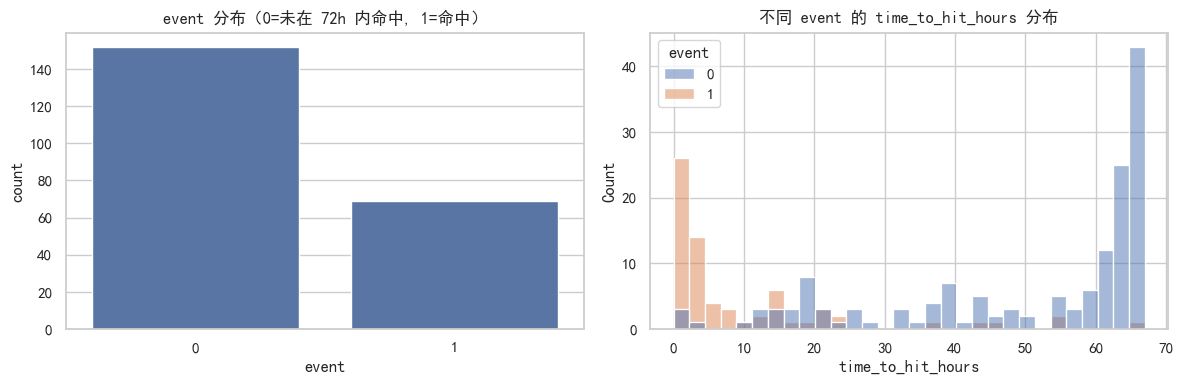

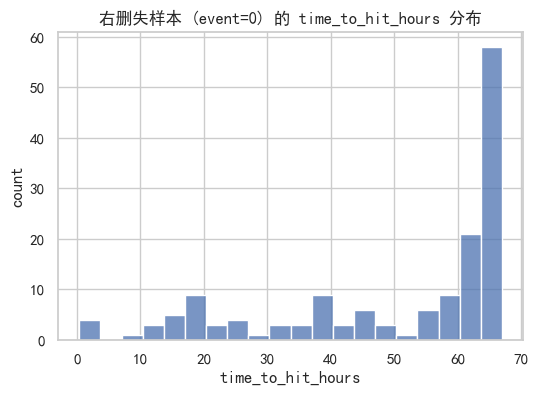

In [20]:
# 二、右删失样本（event = 0）分析：先设置中文字体，再看标签和时间分布

import matplotlib
from matplotlib import font_manager

# 选一个你电脑里有的中文字体名称，比如 SimHei 或 Microsoft YaHei
matplotlib.rcParams["font.sans-serif"] = ["SimHei"]    # 或 ["Microsoft YaHei"]
matplotlib.rcParams["axes.unicode_minus"] = False      # 解决负号显示成方块的问题

# 如果你不确定有哪些字体，可以临时跑下面两行看看所有可用字体
from matplotlib.font_manager import FontManager
sorted(set(f.name for f in FontManager().ttflist))

# 1. 右删失与非删失样本数量、比例
value_counts = train["event"].value_counts().sort_index()
num_censored = value_counts.get(0, 0)
num_events = value_counts.get(1, 0)

print("右删失样本数 (event=0):", num_censored)
print("命中样本数   (event=1):", num_events)
print("右删失比例: {:.2%}".format(num_censored / (num_censored + num_events)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 柱状图：event 分布（0=在 72h 内未烧到 5km，1=在 72h 内烧到 5km）
sns.countplot(x="event", data=train, ax=axes[0])
axes[0].set_title("event 分布（0=未在 72h 内命中, 1=命中）")

# 2. time_to_hit_hours 在不同 event 下的分布（直方图）
sns.histplot(data=train, x="time_to_hit_hours", hue="event", bins=30, kde=False, ax=axes[1])
axes[1].set_title("不同 event 的 time_to_hit_hours 分布")

plt.tight_layout()
plt.show()

# 3. 单独看右删失样本的 time_to_hit_hours 分布（通常会集中在 72 小时附近）
plt.figure(figsize=(6, 4))
subset_censored = train.loc[train["event"] == 0, "time_to_hit_hours"]
sns.histplot(subset_censored, bins=20, kde=False)
plt.title("右删失样本 (event=0) 的 time_to_hit_hours 分布")
plt.xlabel("time_to_hit_hours")
plt.ylabel("count")
plt.show()

# 核心特征与目标关系

本部分挑选与火势发展和疏散风险高度相关的一些核心特征，分析它们与目标变量的关系：

- 选择初始火场面积、面积增长速度、径向扩散速度、最近疏散距离、逼近速度、起火小时等代表性特征；
- 使用箱线图对比不同 `event`（命中/未命中）下特征分布的差异，直观判断哪些因素对是否命中有影响；
- 计算所有数值特征与 `time_to_hit_hours` 的 Pearson 相关系数，找出与到达时间正/负相关最强的一批变量；
- 用条形图展示与 `time_to_hit_hours` 正相关较强的前若干特征，帮助后续特征筛选和模型解释。

用于分析的特征列: ['area_first_ha', 'area_growth_rate_ha_per_h', 'radial_growth_rate_m_per_h', 'dist_min_ci_0_5h', 'closing_speed_m_per_h', 'event_start_hour']


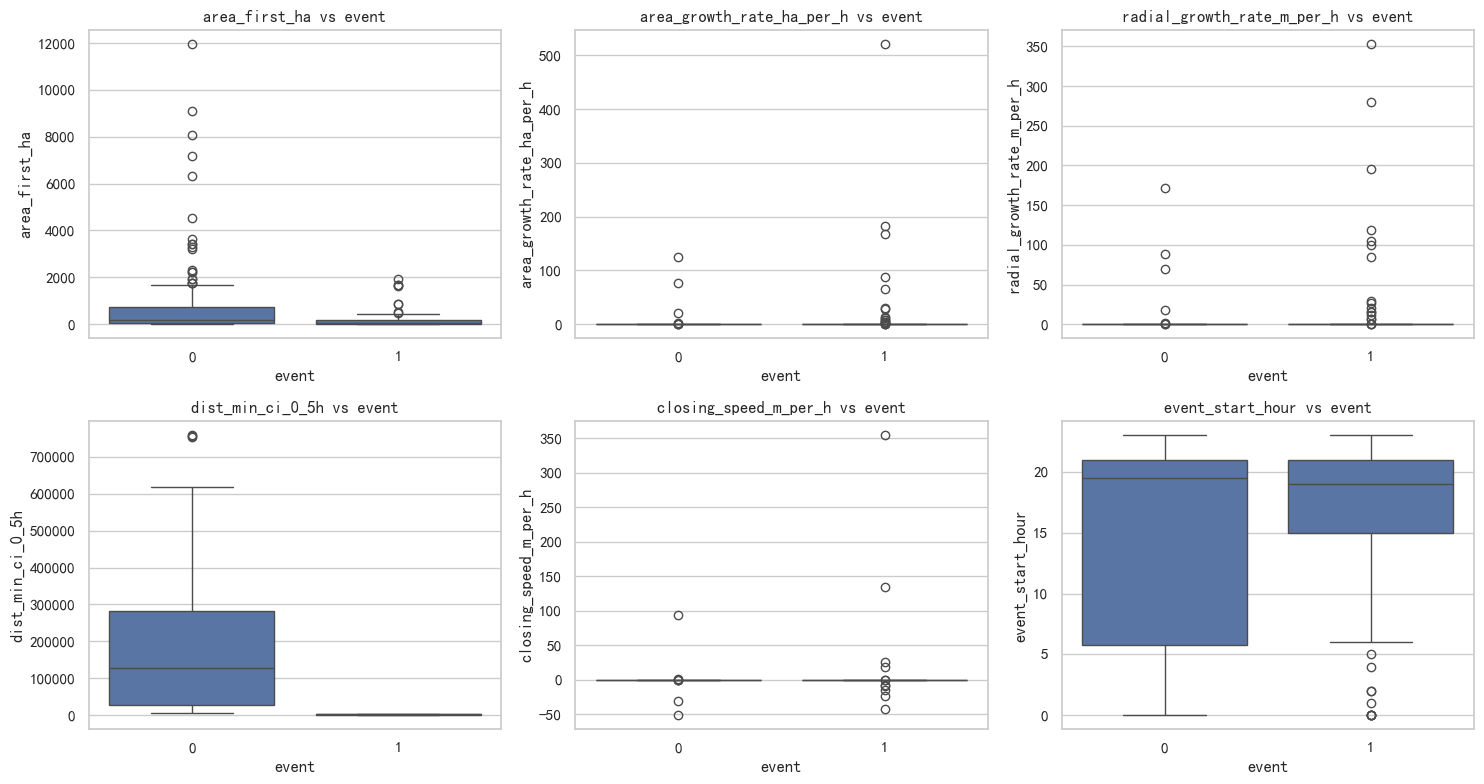


与 time_to_hit_hours 相关性最高的前 15 个特征：
time_to_hit_hours               1.000000
low_temporal_resolution_0_5h    0.442236
spread_bearing_cos              0.370451
dist_min_ci_0_5h                0.324876
area_first_ha                   0.211212
log1p_area_first                0.192067
dist_accel_m_per_h2             0.138790
dist_change_ci_0_5h             0.131773
dist_slope_ci_0_5h              0.125267
event_start_dayofweek           0.123600
event_start_month               0.057934
cross_track_component           0.052684
event_id                        0.003129
along_track_speed              -0.023527
alignment_cos                  -0.079847
Name: time_to_hit_hours, dtype: float64

与 time_to_hit_hours 负相关性最大的前 15 个特征：
closing_speed_abs_m_per_h    -0.166876
area_growth_rate_ha_per_h    -0.177191
centroid_speed_m_per_h       -0.208943
spread_bearing_sin           -0.211706
centroid_displacement_m      -0.212354
radial_growth_m              -0.217379
radial_growth_rate_m_per_h   -0.2181

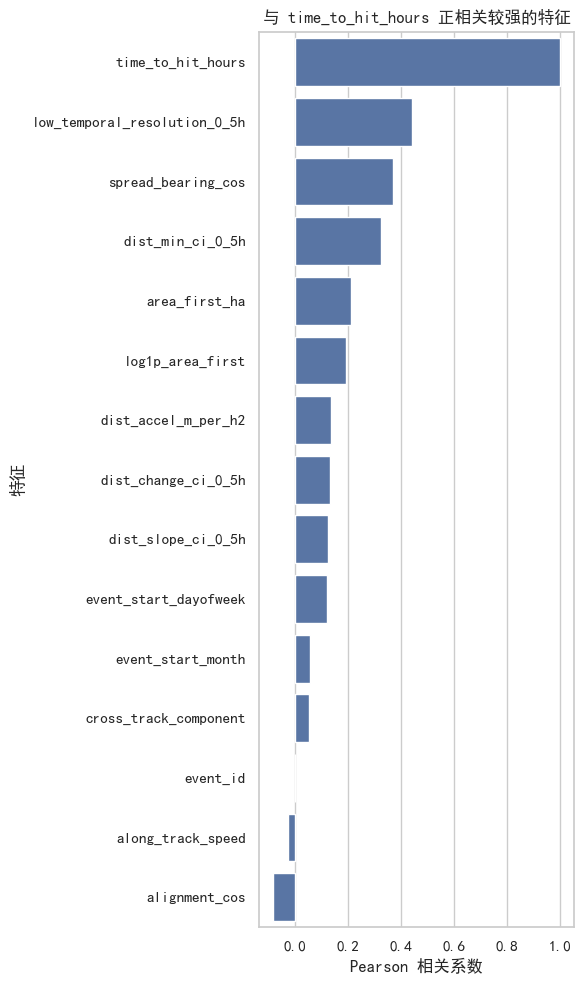

In [21]:
# 三、核心特征与目标变量关系：看特征与 event / time_to_hit_hours 的关系

# 选择一些具有代表性的特征列（可以根据 metaData 再做调整/扩展）
key_features = [
    "area_first_ha",            # 初始火场面积
    "area_growth_rate_ha_per_h",# 面积增长速度
    "radial_growth_rate_m_per_h",# 径向扩散速度
    "dist_min_ci_0_5h",         # 前 5 小时到疏散点的最近距离
    "closing_speed_m_per_h",    # 向疏散点逼近的速度
    "event_start_hour",         # 起火时间（小时）
]

# 过滤掉当前数据里不存在的特征列
existing_features = [c for c in key_features if c in train.columns]
print("用于分析的特征列:", existing_features)

# 1. 不同 event 下特征分布（箱线图），直观对比命中/未命中两类样本
num_cols = len(existing_features)
fig, axes = plt.subplots(nrows=int(np.ceil(num_cols / 3)), ncols=3, figsize=(15, 4 * int(np.ceil(num_cols / 3))))
axes = axes.flatten()

for i, col in enumerate(existing_features):
    sns.boxplot(x="event", y=col, data=train, ax=axes[i])
    axes[i].set_title(f"{col} vs event")

# 如果子图格子比特征多，把多余的子图隐藏掉
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# 2. 计算所有数值特征与 time_to_hit_hours 的 Pearson 相关系数
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_with_time = train[numeric_cols].corr()["time_to_hit_hours"].sort_values(ascending=False)

print("\n与 time_to_hit_hours 相关性最高的前 15 个特征：")
print(corr_with_time.head(15))

print("\n与 time_to_hit_hours 负相关性最大的前 15 个特征：")
print(corr_with_time.tail(15))

# 3. 画条形图展示与 time_to_hit_hours 正相关较强的前 15 个特征
plt.figure(figsize=(6, 10))
sns.barplot(x=corr_with_time.head(15).values, y=corr_with_time.head(15).index)
plt.title("与 time_to_hit_hours 正相关较强的特征")
plt.xlabel("Pearson 相关系数")
plt.ylabel("特征")
plt.tight_layout()
plt.show()